<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-35-ridge-regression-regularization?scriptVersionId=343642019" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #2c3e6b 0%, #2d5496 50%, #1f4080 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #e94560; color: white; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 35</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🧊 Ridge Regularization</h1>
  <p style="color: #a8b2d8; font-size: 17px; margin: 0 0 28px 0; max-width: 620px; line-height: 1.6;">Taming overfitting with L2 penalty — shrink coefficients, not features.</p>
  <div style="display: flex; gap: 24px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 5px">
      <div style="color: #e94560; font-size: 22px; font-weight: 700;">L2</div>
      <div style="color: #8892b0; font-size: 12px; margin-top: 2px;">Penalty Type</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 5px">
      <div style="color: #e94560; font-size: 22px; font-weight: 700;">λ (alpha)</div>
      <div style="color: #8892b0; font-size: 12px; margin-top: 2px;">Regularization Strength</div>
    </div>
    <div style="background: rgba(255,255,255,0.07); border: 1px solid rgba(255,255,255,0.12); border-radius: 10px; padding: 14px 20px; margin: 5px">
      <div style="color: #e94560; font-size: 22px; font-weight: 700;">sklearn</div>
      <div style="color: #8892b0; font-size: 12px; margin-top: 2px;">Ridge · RidgeCV</div>
    </div>
  </div>
</div>
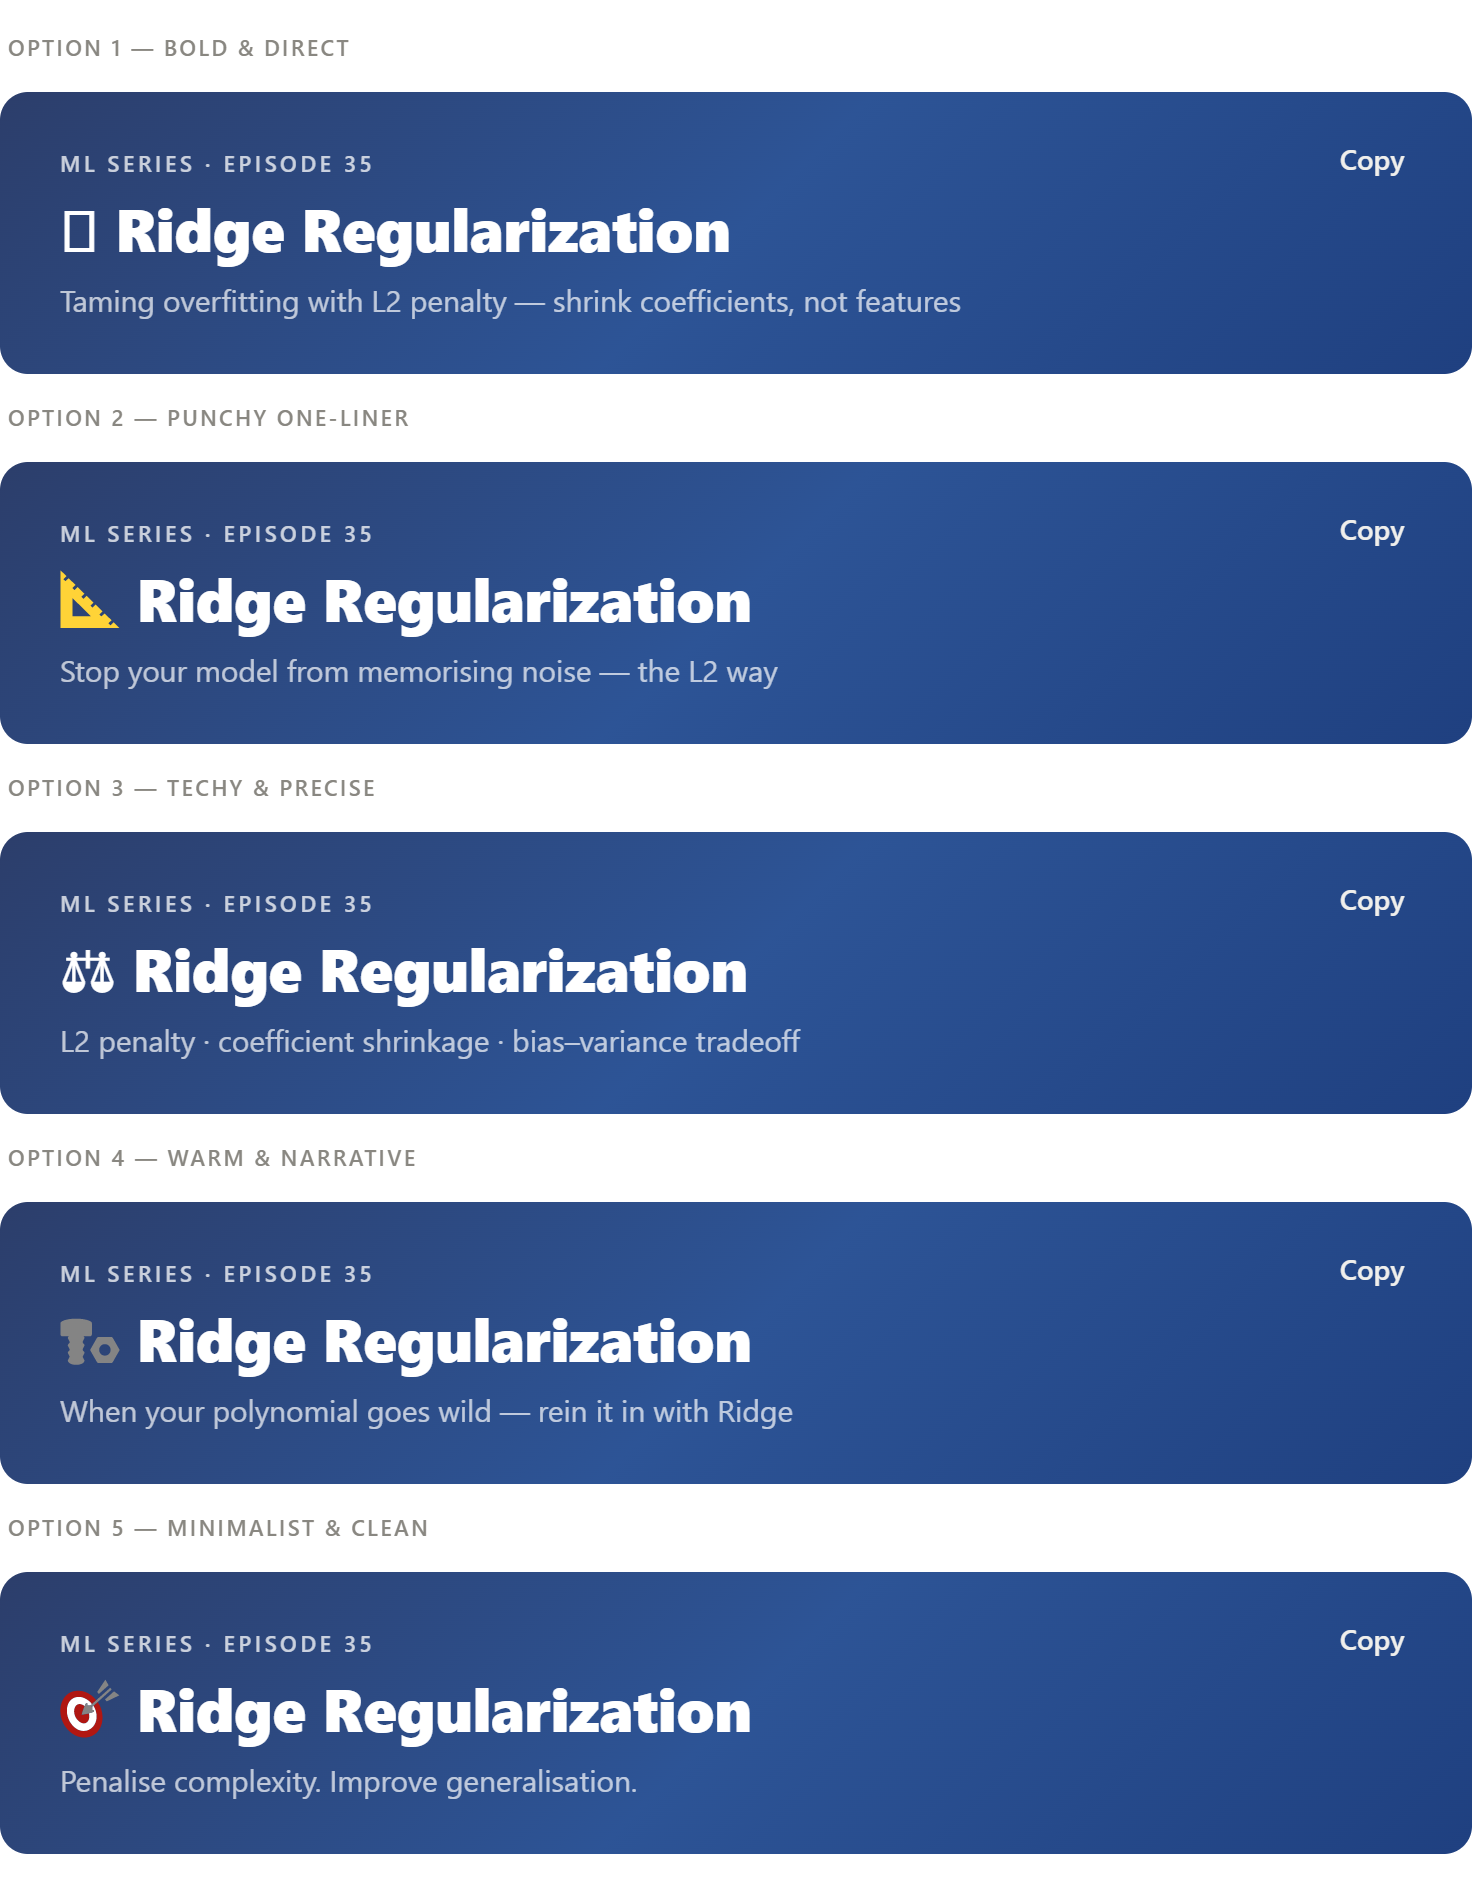

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

In [45]:
data=load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [46]:
X = data.data
y = data.target

In [47]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X, y, random_state=42)

In [48]:
from sklearn.linear_model import LinearRegression

L = LinearRegression()
L.fit(X_train, y_train)

LinearRegression()

In [49]:
print(L.coef_)
print(L.intercept_)

[  47.74968054 -241.99090728  531.97106288  381.56286182 -918.50290455
  508.25778252  116.95016447  269.4923028   695.80811712   26.32458203]
151.6651755919933


In [50]:
y_pred = L.predict(X_test)

In [51]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 score", r2_score(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score 0.4849058889476756
RMSE 53.369566710321955


In [52]:
from sklearn.linear_model import Ridge

R = Ridge(alpha=1)

In [53]:
R.fit(X_train, y_train)

Ridge(alpha=1)

In [54]:
print(R.coef_)
print(R.intercept_)

[  50.55201232  -67.7222237   278.30122846  197.62263845   -6.24583645
  -26.22672623 -151.39433086  120.3233589   215.85446319  101.75577423]
152.51411105005687


In [55]:
y_pred1=R.predict(X_test)

print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score 0.43840029731424435
RMSE 55.72676328702819


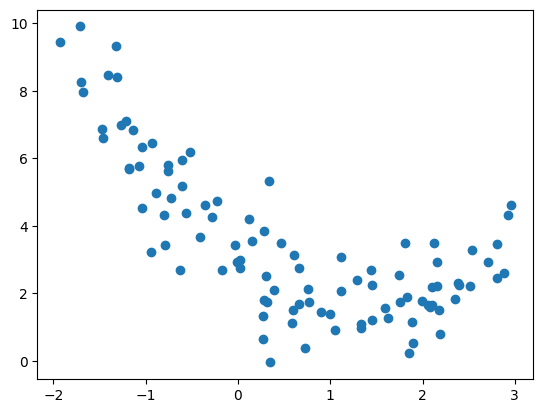

In [56]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

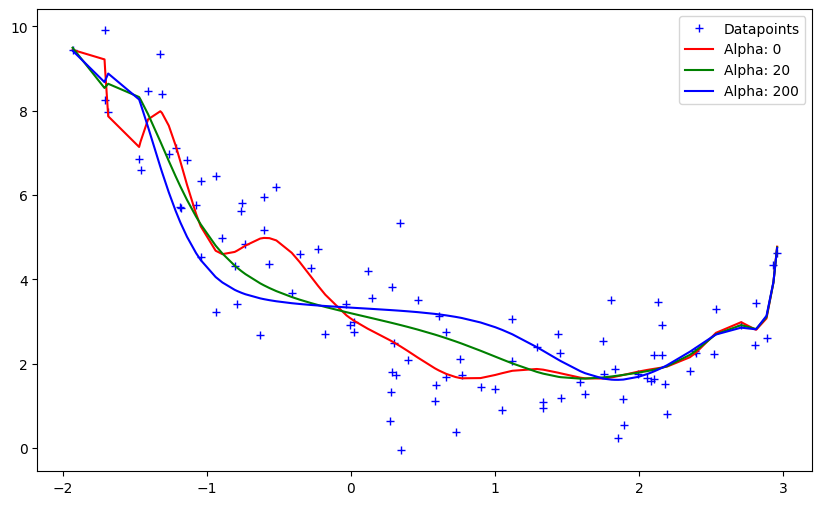

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()